# Machine Learning Engineering 2026 - Final Assignment


#### Name and source statement
Enter your names (in the requested format, please) and your github handle. You can do this assignment alone or in a team of 2. If you are in a team of two, enter both your names below, but submit using a single github account. **Note that Part 4 (RAG pipeline) is treated differently based on your team size.**
For students working alone, Part 4 is an optional bonus question; you can skip it and still receive a full 30/30, or complete it to earn up to 32/30 points. For those working in a team of two, Part 4 is a regular, mandatory requirement, meaning the assignment is graded out of 32/32 points and no bonus is available.


As usual, add a statement on your sources. You are allowed to look up things and use AI tools, but you need to honestly state what you used and how, e.g. to debug code and resolve errors, conceptual understanding, code cleanup or optimization, or generate (partial) solutions. This is required, don't forget.

In [ ]:
# Fill in your name using the given format, GitHub handle, and sources
your_name = "van Rijswijck, Rutger"
second_name = "LAST_NAME, FIRST_NAME" # only if you are working in a pair
github_handle = "Rutger_vr"
statement = """ DID YOU USE ANY LLM/AGENT? HOW?"""


# The Smart Doctor
Skin cancer happens to be one of the most common cancers worldwide, and here's the thing: catching it early makes an enormous difference in patient outcomes. But here's the challenge - accurately classifying skin lesions takes years of training, and even experts sometimes disagree. Similar-looking lesions can be notoriously difficult to tell apart. What if we could build AI systems that learn from hundreds of thousands of cases and give clinicians a second pair of eyes?

---
### Assignment structure

In this assignment, you will step into the role of a machine learning engineer tasked with building the core components of an AI system capable of diagnosing visual anomalies, reasoning through complex clinical queries and staying up-to date with the latest scientific research.

The assignment is divided into four distinct parts:
1. **Vision Diagnostics: CNNs vs. ViTs.** You will start by building the "eyes" of the system. You will fine-tune a classic CNN (e.g., ResNet-18) and a modern ViT on the DermaMNIST dataset to classify skin lesions. Your goal is to compare the two architectures and answer the following question: which approach works better for medical images, and why?

2. **Interpretability.** Accuracy is not enough in the medical domain; doctors need to see what the model sees to validate its prediction. You will implement interpretability techniques to visualize what the model focus on. Your goal is to use GradCAM and Attention Rollout to inspect the CNN and ViT's image focus. You will analyze cases where the model succeeds and, more importantly, where it fails (e.g., focusing on artifacts like hair or ink instead of the lesion).

3. **Fine-tuning with LoRA.** Medicine is also about communication and reasoning, not just image recognition. In this third part you will shift towards NLP tasks. You will implement LoRA to fine-tune the Gemma-3-270M-IT model on a medical dataset. Your goal is to learn to adapt large models to medical reasoning tasks without retraining all parameters. You will also perform hyperparameter optimization to find the best configuration and compare the fine-tuned model against the base model using zero-shot and few-shot evaluation.

3. **(Bonus) Dynamic knowledge: RAG pipeline.** Medical knowledge changes daily with new discoveries and publications. But LLMs are frozen in time, due to the knowledge cutoff during training or the dataset used for fine-tuning. You will build a RAG pipeline using LlamaIndex to ground the LLM's answers in recent medical papers.

---
### Learning Outcomes

By the end of this assignment you will have hands-on experience with:
- **Transfer learning** strategies for both CNN and transformer-based models.
- **Model interpretability** to understand what the models focus on.
- **Parameter-efficient fine-tuning (PEFT)** methods to manage GPU costs.
- **RAG** pipelines to mitigate hallucinations and update knowledge.



## Guidance
This is a much more open assignment than the previous homeworks, and there won't be automated feedback. We highly recommend starting soon and using the labs to get feedback from the TAs and fellow students. You can work in teams of 2 students, although you can also do it individually. If you work as a team:
* Note that the questions build on each other so they can't be easily split between two people. We highly recommend to solve the questions as a team, e.g. by exploring multiple options in parallel and giving feedback to each other.
* Only one person in the team needs to make a submission to GitHub.

### Deliverables
The solution will consist of the following deliverables:
* A report in PDF format of no more than 4 pages in which you clearly explain what you tried and the design decisions that you made to arrive at your final answer. You can include text, tables, and figures. If you include tables  or figures of your results, the data for this should be present in your notebook. You can't show results that are not clearly derived from your code. You can add supporting material such as screenshots from TensorBoard or Weight&Biases to motivate your decisions. This report will be graded.
* This notebook with all your code and the results that you obtained. This notebook must contain all the relevant outputs and all requested outputs such as trained models must be included in you GitHub repo and submitted to GitHub classroom.

### Special variables
Use the path `base_dir='...'` to refer to the folder where you want to store your files while making the assignment. Before submitting, make sure that all your stored models and learning curves are in your GitHub repo root directory and set `base_dir='.\'`

Use variable `skip_training = True` to skip the training of your models when re-running your notebook (including for unit tests).

_Sidenote_: if you use Colab, you can link to a Google Drive and store your models there.
* In Colab, open the 'Files' menu in the left sidebar, and click 'Mount Drive'
* Create a folder in your Drive to store assignment files and set `base_dir` to that directory
  * E.g. it could be `base_dir = '/content/drive/MyDrive/assignment'`

### Using GPUs
Using a GPU will speed up training a lot. You have a number of options (and also combine them):
* If you have a local GPU, you can use that for most model exploration. If you have a Windows system [see here for tips on installing CUDA](https://docs.nvidia.com/cuda/cuda-installation-guide-microsoft-windows/), if you haven't already.
* You can use Google Colab. In Runtime > Change runtime type, select a GPU under Hardware Accelerator. T4 is ok for initial experiments, A100 only makes sense for larger models. Note that credits on Colab are limited, especially on a free plan.
* Use the HPC resources on the Snellius supercomputer. We did a tutorial during the labs. You can also [find the slides on Canvas](https://canvas.tue.nl/courses/28782/files).
* If you run out of memory by running the whole notebook sequentially we suggest running the different parts separately. In particular, for *Part 3 : Fine-tuning with LoRA* and *Part 4: RAG pipeline* we suggest reinitializing the runtime and only install the required dependencies and loading the required models and datasets.

Take this into account in your planning, so that you don't do all your training at the last moment and are locked out or waiting in queues before the deadline. You can do initial experiments locally (or on Colab if you don't have a GPU), then use the supercomputer only for large-scale experiments.

### Tips
* Don't wait until the last minute to do the assignment. The models take time to train, most questions will require some thinking, and some require you to read up on some new concepts. Don't trust AI tools to quickly solve the questions for you at the last minute.
* Take care that you upload the results as requested. You need to submit not only the notebooks but also the trained models and learning curves (training histories). Be sure to check that all the results are included.
* The datasets we will use are quite large and they can take a while to download and cache for the first time. Once cached, they should load fast. Even if you use Colab, at least run the notebook once locally when you start doing the assignment (i.e., now).
* Explore. For many questions we'll ask you to explain your model design decisions. You cannot magically know the best solutions but you can experiment based on your understanding and make decisions based on both your knowledge and experiments. Your explanation is at least as important as the performance of your model. Don't say 'I tried every possible option and this is the best I found', but rather 'I tried X because I think that Y' and then interpret the results and what you learned from them'.
* **Be original. We will check for plagiarism between student submissions.**

##### **Tips on using AI tools**
From experiences over the last years in this and other courses, we learned that the quality of assignment solutions has (somewhat surprisingly) gone down with the arrival of AI tools. This is in part because chatbots may not fully understand the question and thus make mistakes, but primarily because AI tools cause students to interact less with each other, and more often postpone work too long. Recommendations:
* Using AI can help you do better ML engineering, but requires solid ML knowledge and programming skills to begin with to critically assess the responses. Make sure you understand the concepts taught in the course and do the labs first.
* Talk to fellow students (and the teaching team). Don't copy code but do ask questions and learn from each other. Share the enthusiasm of learning and solving problems.
* Always try to solve the assignment by yourself so that you really understand the question and the challenges. Using AI to understand and resolve errors, or to explain vague concepts is fine.


Now, let's get started ;)

## Setting up our environment

In [1]:
# Install required packages
!pip install torch torchvision medmnist matplotlib seaborn scikit-learn tqdm trl datasets transformers peft wandb -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from tqdm.notebook import tqdm
import functools
# import cv2
import medmnist
from medmnist import INFO
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score
import seaborn as sns
import pandas as pd
from typing import Dict, List, Tuple
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize

from huggingface_hub import notebook_login
from datasets import load_dataset, DatasetDict
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer
import re
import json
import random
import wandb

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"MedMNIST version: {medmnist.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.5.1+cu121
MedMNIST version: 3.0.2
CUDA available: True


In [50]:
### CHANGE WITH YOUR BASE_DIR PATH
base_dir = '.\\'        # Where to save your outputs
skip_training = False  # Set True to load saved models instead of retraining

## Part 1: CNNs vs. ViTs (10 points)

In this part, we will fine-tune ResNet-18 and a Vision Transformer (ViT-B-16) on the DermaMNIST dataset and compare their performance.

Your primary tasks in this section are as follows:

- Fine-tune a ResNet-18 model on the DermaMNIST dataset.
- Fine-tune a Vision Transformer (ViT-Base) model on the same dataset.
- Compare the two models in terms of classification performance, computational efficiency, and training dynamics.
- Analyze the results to draw conclusions about the suitability of CNNs and transformer-based models for the given dataset.
  
We provide data loaders, some helper functions and several hints along the way to help you get started. You are expected to make use of these utilities and may modify them if needed.

### Your tasks:

**T1. Model Setup and Training**

Start by loading pre-trained weights (eg. ImageNet) for both models and modify the architectures so they are suitable for DermaMNIST.

Implement a full training pipeline. This should include a data augmentation strategy appropriate for dermoscopic images, a loss function, and an optimizer with clearly specified hyperparameters (learning rate, weight decay, etc.). If you use a learning rate scheduler or regularization techniques such as early stopping or dropout, briefly explain your reasoning and their effect on training.

**T2. Fine-Tuning**

Decide how you will fine-tune each model. You may fine-tune all layers, freeze part of the network and train only the classifier head, or use a progressive unfreezing strategy. Justify your choice based on factors such as dataset size, training stability, overfitting risk, or computational constraints.

During training, track:

- training and validation loss per epoch,
- training and validation accuracy per epoch,
- training time per epoch,
- and the number of trainable versus frozen parameters.

Use these metrics to support your discussion.

**T3. Model Evaluation**

Evaluate both models on the test set using the provided `evaluate()` function. Report with metrics such as classification accuracy, confusion matrix, etc. Use these results to highlight strengths and weaknesses of each model.

**Good to know:** A test accuracy of around 70-80% is achievable for both ViTs and ResNets. Try at least two or three different configurations for both the ResNet and the ViT models. The goal is not to achieve the highest accuracy, but to improve your understanding on which techniques work better/worse for a given situation.

---
**Grading**

You can gain a total of 10 points in this part. 6 points will be assigned if your code is correct and you give a clear and detailed explanation of your design process and design decisions. Try to be detailed but stay to the point, remain professional, and try to remain within 2 pages (less is also ok). Discuss the following:

A. Challenges Encountered

For each model, describe the main challenges you faced (e.g. unstable training, slow convergence, overfitting, etc). Explain what strategies you tried to address them, such as data augmentation, regularization, learning rate changes, or layer freezing. Be clear about what worked and what didn't, and support your claims with evidence from training curves or evaluation accuracy.

B. Model Comparison

Compare ResNet-18 and ViT-Base in terms of classification performance, training dynamics, and computational efficiency. Discuss which model performed better overall and whether certain classes benefited more from one architecture. Some questions that might guide your discussion are as follows. Which model achieved higher accuracy? Are there particular disease classes where one model excels? Did you observe any overfitting while training? How did you address it? Which hyperparameters had the biggest impact on each model? Which model is more practical for deployment in terms of accuracy and training time? What does the confusion matrix tell you about each model's decision-making?

The other 4 points depend on the how good your models are (accuracy), evaluated on the test set. Only correct solutions count for this. If your code contains errors, some points may be deducted for that.

In [ ]:
# Feel free to change configurations while training different models in this section
CONFIG = {
    'data_flag': 'dermamnist',
    'download': True,
    'size': 224,
    'batch_size': 64,
    'num_epochs': 20,
    'learning_rate': 0.001,
    'num_workers': 0,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

print(f"Using device: {CONFIG['device']}")
print(f"Image size: {CONFIG['size']}x{CONFIG['size']}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Number of epochs: {CONFIG['num_epochs']}")

Using device: cuda
Image size: 224x224
Batch size: 64
Number of epochs: 20


#### Section 1.1 - Load and understand the data
**DermaMNIST** is a collection of skin lesion images that reflects the real-world challenges of medical AI. Medical datasets tend to be small and expensive to create. Each image needs to be carefully labeled by experts, and certain conditions are naturally rarer than others.

Our dataset contains seven different types of skin lesions, ranging from benign growths to melanoma, the most dangerous form of skin cancer. The training set has around 7,000 images - which is quite typical for medical applications. This constraint is going to be important as we think about which architecture might work better.

Let's look at the seven classes we'll be working with:

| Class | What It Is | Why It Matters |
|-------|------------|----------------|
| Actinic keratoses | Pre-cancerous sun damage | Catching these prevents progression |
| Basal cell carcinoma | Most common skin cancer | Highly curable if detected early |
| Benign keratosis | Harmless growths | Shouldn't be confused with cancer |
| Dermatofibroma | Benign skin nodules | Typically straightforward to diagnose |
| Melanoma | Aggressive skin cancer | Critical to detect - mistakes are costly |
| Melanocytic nevi | Common moles | Benign, but look similar to melanoma |
| Vascular lesions | Blood vessel growths | Usually distinct in appearance |

Here's something to keep in mind as you train your models: the distinction between melanoma and nevi is quite difficult, even for human experts. These two classes are the ones most likely to get confused, and when you look at your confusion matrices later, pay special attention to how your models handle this critical distinction.

**Note:** If you are using a Windows local setup, change `num_workers = 0`. Loading the dataset for the first time might take a bit longer in this case (~10 minutes).

In [9]:
# This is an helper function to create dataloaders
# You can change the augmentation function in this code cell
def get_data_loaders(batch_size: int = 64) -> Tuple[DataLoader, DataLoader, DataLoader, int]:
    """
    Load and prepare the DermaMNIST dataset.

    Returns train, validation, and test loaders plus the number of classes.
    """
    info = INFO['dermamnist']
    n_classes = len(info['label'])
    DataClass = getattr(medmnist, info['python_class'])

    print(f"\n{'='*60}")
    print(f"Loading DermaMNIST Dataset")
    print(f"{'='*60}")
    print(f"\nWe have {n_classes} classes to work with:")
    for idx, name in info['label'].items():
        print(f"  {idx}: {name}")
    print(f"{'='*60}\n")

    # normalization
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # mean from ImageNet dataset
        std=[0.229, 0.224, 0.225]    # std from ImageNet dataset
    )

    # Training transform with augmentation
    # feel free to change
    train_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    # validation/test transform
    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    # load the datasets
    train_dataset = DataClass(split='train', transform=train_transform, download=True, size=224)
    val_dataset   = DataClass(split='val',   transform=eval_transform, download=True, size=224)
    test_dataset  = DataClass(split='test',  transform=eval_transform, download=True, size=224)

    def collate_fn(batch):
        images, labels = zip(*batch)
        images = torch.stack(images)
        labels = torch.tensor([label.item() if hasattr(label, 'item') else label.flatten()[0]
                              if hasattr(label, 'flatten') else label
                              for label in labels], dtype=torch.long)
        return images, labels

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0, collate_fn=collate_fn)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_fn)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_fn)

    print(f"Dataset splits:\n")
    print(f"  Training:   {len(train_dataset):,} images")
    print(f"  Validation: {len(val_dataset):,} images")
    print(f"  Test:       {len(test_dataset):,} images\n")

    return train_loader, val_loader, test_loader, n_classes

# the execution might take a while since we load images with size 224 x 224
train_loader, val_loader, test_loader, n_classes = get_data_loaders(CONFIG['batch_size'])


Loading DermaMNIST Dataset

We have 7 classes to work with:
  0: actinic keratoses and intraepithelial carcinoma
  1: basal cell carcinoma
  2: benign keratosis-like lesions
  3: dermatofibroma
  4: melanoma
  5: melanocytic nevi
  6: vascular lesions

Using downloaded and verified file: C:\Users\20212348\.medmnist\dermamnist_224.npz
Using downloaded and verified file: C:\Users\20212348\.medmnist\dermamnist_224.npz
Using downloaded and verified file: C:\Users\20212348\.medmnist\dermamnist_224.npz
Dataset splits:

  Training:   7,007 images
  Validation: 1,003 images
  Test:       2,005 images



Each batch has shape: torch.Size([64, 3, 224, 224])
That's (batch_size, channels, height, width)



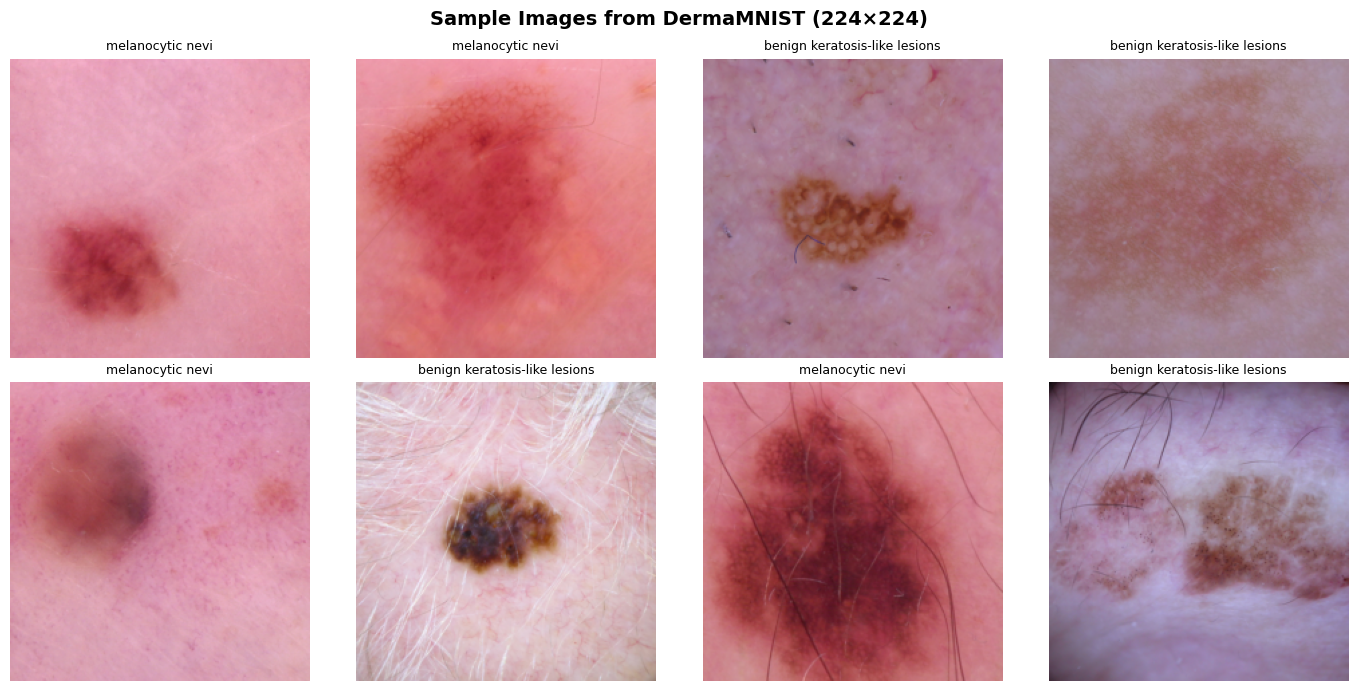

In [10]:
class_names = {i: INFO['dermamnist']['label'][str(i)] for i in range(n_classes)}
images, labels = next(iter(train_loader))

print(f"Each batch has shape: {images.shape}")
print(f"That's (batch_size, channels, height, width)\n")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for i in range(8):
    img = images[i].numpy().transpose((1, 2, 0))
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img = np.clip(std * img + mean, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()], fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample Images from DermaMNIST (224×224)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Section 1.2 -Some helper functions

In [11]:
# This is an helper function to evaluate your model.
# Do not modify it, unless necessary
def evaluate(model, data_loader, criterion=None, device='cuda'):
    """
    Evaluation function

    Args:
        model: The model being evaluated
        data_loader: DataLoader (validation or test set)
        criterion: Loss function
        device: Device to run on

    Returns:
        all_preds: numpy array of predictions
        all_labels: numpy array of true labels
        accuracy: accuracy percentage
        loss: average loss (None if criterion not provided)
    """
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if criterion is not None:
                loss = criterion(outputs, labels)
                running_loss += loss.item()


            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy = 100. * (all_preds == all_labels).sum() / len(all_labels)
    avg_loss = running_loss / len(data_loader) if criterion is not None else None

    print(f"######## Test Accuracy: {accuracy:.2f}% ########")

    return all_preds, all_labels, accuracy, avg_loss

# This is an helper function to plot the training history.
# Do not modify it, unless necessary
def plot_training_history(history, model_name):
    """Plot training and validation curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'{model_name} - Loss Curves', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
    ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title(f'{model_name} - Accuracy Curves', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f'{model_name}_training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()


#### Section 1.3 -Load and fine-tune a pre-trained ResNet-18 model

**Your task:** Load a ResNet-18 model and fine-tune it with transfer learning for the 7-class skin lesion classification task. Plot the learning curves while training and evaluate the model on the test set.

**Hints:**
- Load the pre-trained ResNet-18 from `torchvision.models` (use `pretrained=True`)
- Remember that the final fully-connected layer of ResNet-18 (`model.fc`) outputs 1000 classes for ImageNet. Do you need to modify this?
- Write a training loop (or a `train_model` function) that runs for `num_epochs`, computes cross-entropy loss, back-propagates, and records train/val accuracy and loss for each epoch
- Try different hyperparameter configurations, e.g., optimizer, learning rate, number of epochs, etc., to find the best set
- Save the best model checkpoint (by validation accuracy) using `torch.save(model.state_dict(), ...)`
- For plotting the learning curves you can check the `plot_training_history` helper function
- For evaluation on the test set you can use the `evaluate()` helper function, passing in `test_loader`


In [36]:
### YOUR IMPLEMENTATION HERE (Model loading)

freeze_base = True

# 1. Load the pre-trained ResNet-18 model
# Note: While the hint mentions 'pretrained=True', modern PyTorch prefers 'weights="DEFAULT"' 
# to load the best available ImageNet weights.
resnet_model = models.resnet18(weights='DEFAULT')

# OPTIONAL: Freeze all base layers
if freeze_base:
    for param in resnet_model.parameters():
        param.requires_grad = False

# 2. Get the number of input features going into the final fully connected (fc) layer
num_ftrs = resnet_model.fc.in_features

# 3. Replace the final layer with a new one tailored to our specific number of classes
resnet_model.fc = nn.Linear(num_ftrs, n_classes)

# 4. Move the model to the device (GPU or CPU) specified in our CONFIG
resnet_model = resnet_model.to(CONFIG['device'])

print(f"ResNet-18 successfully loaded!")
print(f"Final layer modified to take {num_ftrs} inputs and output {n_classes} classes.")
print(f"Model moved to: {CONFIG['device']}")

ResNet-18 successfully loaded!
Final layer modified to take 512 inputs and output 7 classes.
Model moved to: cuda


In [49]:
### YOUR IMPLEMENTATION HERE (Training function)

import time
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, model_name="model"):
    """
    Trains and validates a PyTorch model, saving the best weights based on validation accuracy.
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    #Calculate and print trainable vs. frozen parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f"--- Model Complexity ---")
    print(f"Total Parameters: {trainable_params + frozen_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Frozen Parameters: {frozen_params:,}")
    print(f"------------------------\n")
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        epoch_start_time = time.time()
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloader, desc=f"{phase.capitalize()} Phase", leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                # Track history only if in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = (running_corrects.double() / len(dataloader.dataset)).item() * 100

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}%")

            # Save to history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)

                # Deep copy the model if we got a new best validation accuracy
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    # Save the physical file as requested in the assignment
                    save_path = os.path.join(base_dir, f'best_{model_name}.pth')
                    torch.save(model.state_dict(), save_path)
                    print(f"New best model saved to {save_path}!")

        #Calculate the duration of the epoch and save it
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time
        history['epoch_time'].append(epoch_duration)
        
        # Print epoch time formatted as minutes and seconds
        mins = epoch_duration // 60
        secs = epoch_duration % 60
        print(f"Epoch {epoch+1} completed in {mins:.0f}m {secs:.0f}s\n")
        
        print() # Empty line for readability

    print(f"Training complete. Best Val Acc: {best_acc:.2f}%")
    
    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return model, history

# --- Setup and Execution ---

# 1. Define Loss Function 
# criterion = nn.CrossEntropyLoss()

train_labels = train_loader.dataset.labels.squeeze()

# 2. Count the occurrences of each class using Numpy
class_counts = np.bincount(train_labels)

# 3. Calculate class weights
total_samples = len(train_labels)
class_weights = [total_samples / c for c in class_counts]

# Convert to a tensor and move to your device
weights_tensor = torch.FloatTensor(class_weights).to(CONFIG['device'])

# Pass it to your loss function
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# 2. Define Optimizer (Adam is a great default, using the learning rate from your CONFIG)
optimizer = optim.Adam(resnet_model.parameters(), lr=1e-4, weight_decay=1e-4)

# 3. Train the model! (This will take a few minutes depending on your hardware)
print("Starting ResNet-18 Training...")
if not skip_training:
    resnet_model, resnet_history = train_model(
        model=resnet_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=CONFIG['num_epochs'],
        device=CONFIG['device'],
        model_name="resnet18"
    )
else:
    print("skip_training is set to True. If you want to train, set it to False in the config block above!")
    # Note: If you skip training, you'll need to load a pre-trained local file here if you have one.

Starting ResNet-18 Training...
skip_training is set to True. If you want to train, set it to False in the config block above!


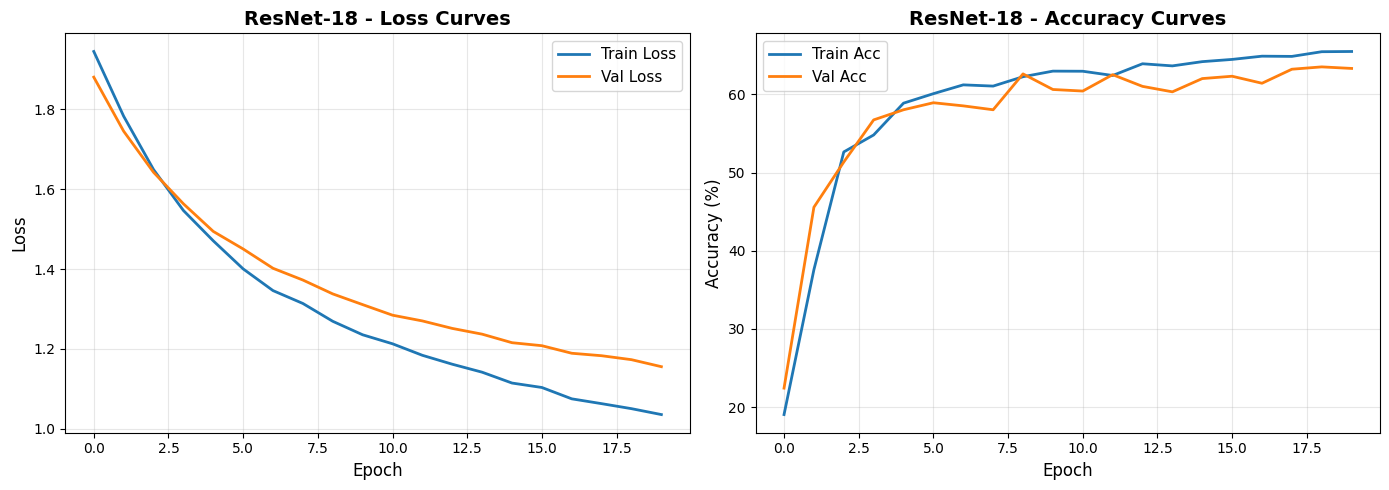

In [38]:
### YOUR IMPLEMENTATION HERE (Plots)
# Check the `plot_training_history()` helper function above

if 'resnet_history' in locals():
    plot_training_history(resnet_history, "ResNet-18")
else:
    print("No training history found. Make sure to train the model or load a saved history before plotting.")


In [39]:
### YOUR IMPLEMENTATION HERE (Evaluation on test set)
# Check the `evaluate()` helper function above

print("Evaluating ResNet-18 on the Test Set...")

# We use the criterion we defined earlier to also get the test loss
resnet_preds, resnet_labels, resnet_acc, resnet_loss = evaluate(
    model=resnet_model, 
    data_loader=test_loader, 
    criterion=criterion, 
    device=CONFIG['device']
)

if resnet_loss is not None:
    print(f"Test Loss: {resnet_loss:.4f}")

Evaluating ResNet-18 on the Test Set...


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

######## Test Accuracy: 64.54% ########
Test Loss: 1.1818


#### Section 1.4 - Confusion matrix
Accuracy alone can be misleading - especially on an imbalanced dataset like DermaMNIST. A model that simply learns to predict the majority class most of the time can still achieve a decent accuracy number while not being useful in practice. With a confusion matrix, you can immediately see:

- **Which classes the model struggles with** - are the errors scattered, or does the model systematically confuse certain pairs?
- **The cost of errors** - in a medical setting, not all mistakes are equal. Which misclassifications here would you consider most dangerous?
- **The effect of class imbalance** - do some classes dominate the predictions? What could that tell you about the model's behaviour?

**Hint:** Consider using `confusion_matrix()` from `sklearn.metrics` and visualise with `seaborn.heatmap()`. Label both axes with `class_names`. Check that you're passing `(true_labels, predicted_labels)` in that order.

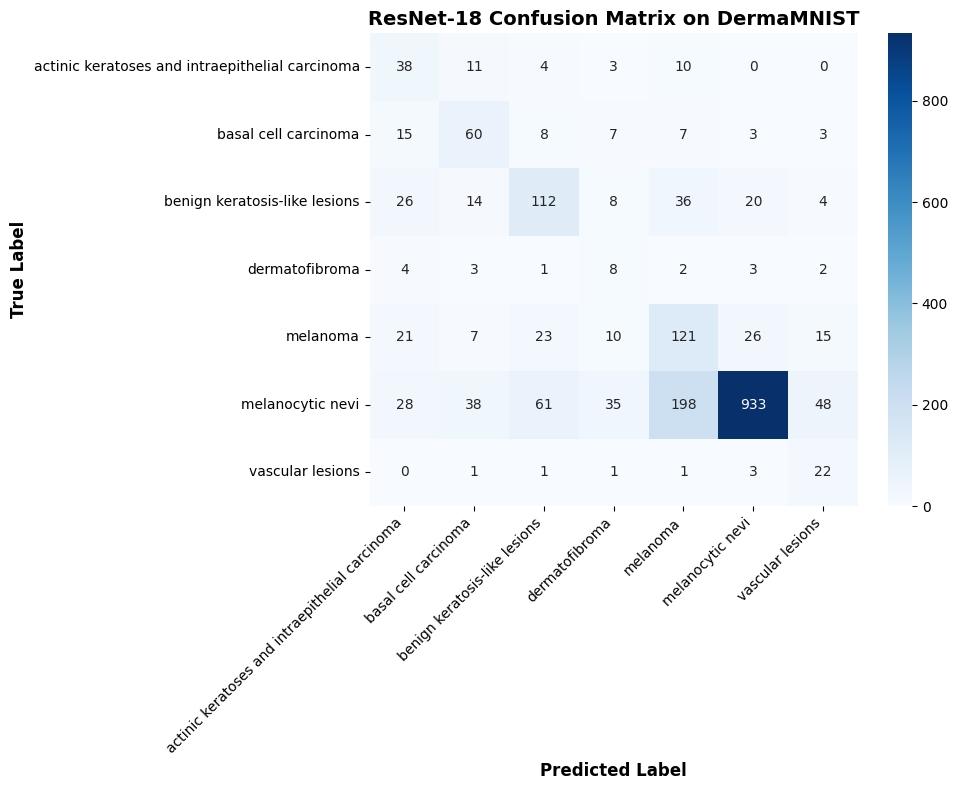

In [40]:
### YOUR IMPLEMENTATION HERE (Confusion matrix)

# Create the confusion matrix
cm = confusion_matrix(resnet_labels, resnet_preds)

# Get the list of class names in the correct order for the axes
labels = [class_names[i] for i in range(n_classes)]

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Plot the heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

# Add labels and title
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.title('ResNet-18 Confusion Matrix on DermaMNIST', fontsize=14, fontweight='bold')

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'resnet18_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Section 1.5 - Load and fine-tune a pre-trained ViT model

**Your task:** Load a ViT-Base model and fine-tune it with transfer learning for the 7-class skin lesion classification task. Plot the learning curves while training and evaluate the model on the test set. Finally plot a confusion matrix to better understand the prediction errors.

**Hints:**
- Load the pre-trained Vit-base from `torchvision.models` with `torchvision.models.vit_b_16(pretrained=True)`. This is the ViT-Base architecture with 16x16 patch size
- The classification head is at `model.heads.head` (not `model.fc` like ResNet). Check its `in_features` and replace it with a `nn.Linear(in_features, n_classes)`
- ViT is larger (~86M params vs ~11M for ResNet), so training will be slower!
- Use the **same training loop** you wrote for ResNet (or the same `train_model` function) so the comparison is fair
- You might need to change the set of hyperparameters, e.g., optimizer, learning rate, number of epochs, etc.
- Save the best model checkpoint (by validation accuracy) using `torch.save(model.state_dict(), ...)`
- For plotting the learning curves you can check the `plot_training_history` helper function :)
- For evaluation on the test set you can use the `evaluate()` helper function, passing in `test_loader`
- For the confusion matrix we suggest using the same code as before

In [44]:
### YOUR IMPLEMENTATION HERE (Model loading)
# 1. Load the pre-trained ViT-Base model (16x16 patch size)
vit_model = models.vit_b_16(weights='DEFAULT')

#Freeze base layers
for param in vit_model.parameters():
    param.requires_grad = False

# 2. Find the in_features for the classification head
# Note: Unlike ResNet's `model.fc`, the ViT head is located at `model.heads.head`
num_ftrs_vit = vit_model.heads.head.in_features

# 3. Replace the head to output our 7 DermaMNIST classes
vit_model.heads.head = nn.Linear(num_ftrs_vit, n_classes)

# 4. Move the model to the target device
vit_model = vit_model.to(CONFIG['device'])

print(f"ViT-Base-16 successfully loaded!")
print(f"Final layer modified to take {num_ftrs_vit} inputs and output {n_classes} classes.")
print(f"Model moved to: {CONFIG['device']}")

ViT-Base-16 successfully loaded!
Final layer modified to take 768 inputs and output 7 classes.
Model moved to: cuda


In [ ]:
# # CLEARING CUDA CACHE

# import gc

# # Run Python's garbage collector
# gc.collect()

# # Empty PyTorch's CUDA cache
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
#     print("CUDA cache cleared!")

CUDA cache cleared!


In [51]:
### YOUR IMPLEMENTATION HERE (Training function)
# You should use the same function implemented before
# If you need any adjustment do it here
# Otherwise delete this cell

# Define Optimizer specifically for the ViT model
# We use a slightly lower learning rate (3e-5) which often works better for ViTs
optimizer_vit = optim.Adam(vit_model.parameters(), lr=3e-5, weight_decay=1e-4)

print("Starting ViT-Base Training (This will take longer than ResNet!)...")
if not skip_training:
    vit_model, vit_history = train_model(
        model=vit_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,  # Re-using the same weighted loss from our ResNet tweaks
        optimizer=optimizer_vit,
        num_epochs=CONFIG['num_epochs'],
        device=CONFIG['device'],
        model_name="vit_base"
    )

Starting ViT-Base Training (This will take longer than ResNet!)...
--- Model Complexity ---
Total Parameters: 85,804,039
Trainable Parameters: 5,383
Frozen Parameters: 85,798,656
------------------------

Epoch 1/20
----------


Train Phase:   0%|          | 0/110 [00:00<?, ?it/s]

Train Loss: 1.8842 Acc: 36.95%


Val Phase:   0%|          | 0/16 [00:00<?, ?it/s]

Val Loss: 1.8395 Acc: 45.66%
New best model saved to .\best_vit_base.pth!
Epoch 1 completed in 4m 19s


Epoch 2/20
----------


...

Val Loss: 1.3027 Acc: 63.11%
Epoch 19 completed in 4m 48s


Epoch 20/20
----------


Train Phase:   0%|          | 0/110 [00:00<?, ?it/s]

Train Loss: 1.1952 Acc: 64.62%


Val Phase:   0%|          | 0/16 [00:00<?, ?it/s]

Val Loss: 1.2914 Acc: 63.21%
Epoch 20 completed in 4m 48s


Training complete. Best Val Acc: 63.31%


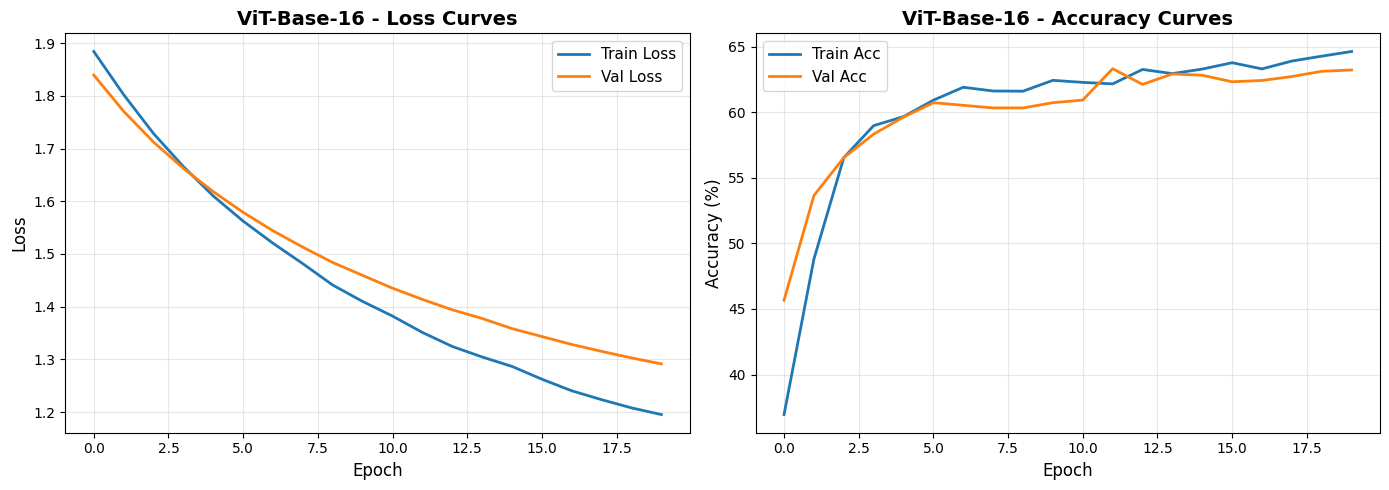

In [52]:
### YOUR IMPLEMENTATION HERE (Plots)
# Check the `plot_training_history()` helper function above
if 'vit_history' in locals():
    plot_training_history(vit_history, "ViT-Base-16")
else:
    print("No training history found. Make sure to train the model or load a saved history before plotting.")

In [53]:
### YOUR IMPLEMENTATION HERE (Evaluation on test set)
# Check the `evaluate()` helper function above
print("Evaluating ViT-Base on the Test Set...")

vit_preds, vit_labels, vit_acc, vit_loss = evaluate(
    model=vit_model, 
    data_loader=test_loader, 
    criterion=criterion, 
    device=CONFIG['device']
)

if vit_loss is not None:
    print(f"Test Loss: {vit_loss:.4f}")

Evaluating ViT-Base on the Test Set...


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

######## Test Accuracy: 63.54% ########
Test Loss: 1.3424


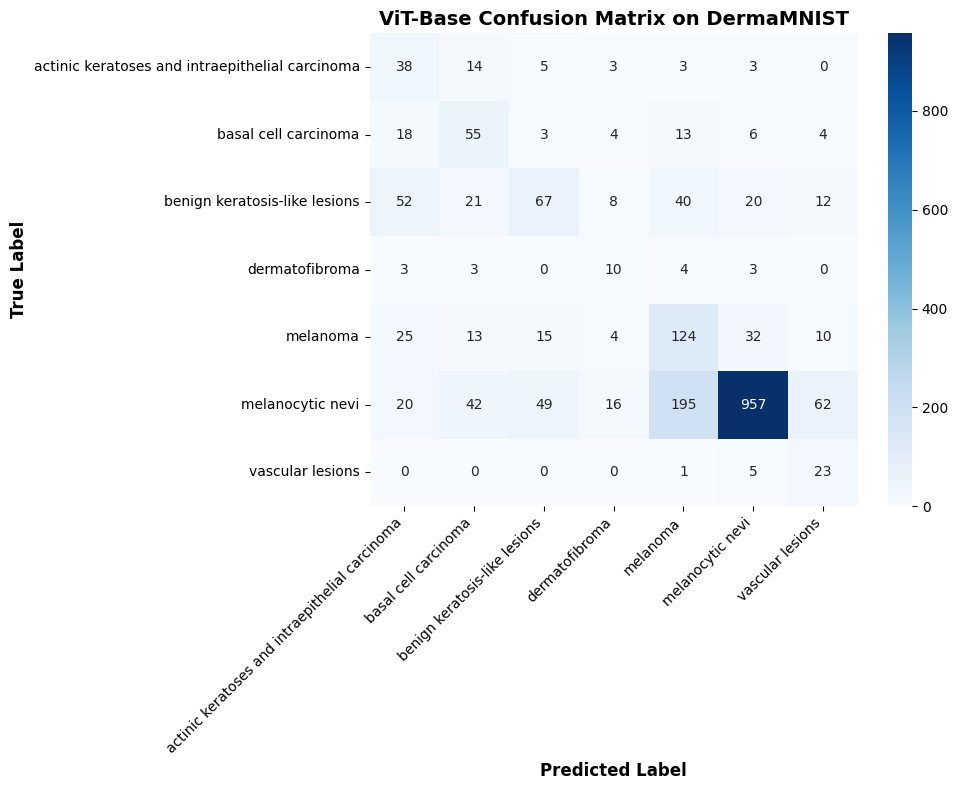

In [56]:
### YOUR IMPLEMENTATION HERE (Confusion matrix)

# Create the confusion matrix for ViT
cm_vit = confusion_matrix(vit_labels, vit_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.title('ViT-Base Confusion Matrix on DermaMNIST', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'vit_base_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Model interpretability (10 points)

In the previous part, you fine-tuned ResNet-18 and ViT-Base to classify skin conditions using the DermaMNIST dataset.

In healthcare, a "black-box" model that makes correct prediction for the wrong reasons is dangerous. For instance, a model might learn to rely on artifacts specific to the lighting of an hospital room rather than the skin lesion itself. To trust these models, clinicians and engineers must understand what the model is looking at and where it is focusing its attention.

The purpose of this part is to delve more into model interpretability. You will implement and apply the following techniques:
- GradCAM: to visualize convolutional features in ResNet-18.
- Attention rollout: to inspect the self-attention mechanisms of the ViT.

### Your Tasks:

**T1. Qualitative Case Study**

Select 5 diverse images from the test set of DermaMNIST that meet the following criteria:
- Image A: an image where both models predict the correct class with high confidence.
- Image B: an image where both models predict the correct class, but with low confidence (e.g., probability between 0.4 and 0.6)
- Image C: an image where the CNN is correct but ViT is incorrect.
- Image D: an image where ViT is correct but the CNN is incorrect.
- Image E: any image containing an artifact (e.g., a hair, ink markings).

**T2. Implementation of interpretability techniques**

Implement and apply the following visualization methods to your fine-tuned models:
* Grad-CAM: To visualize the gradients and feature maps of the final convolutional layers in ResNet-18.
* Attention Rollout: To aggregate and inspect the self-attention weights across the multiple heads and layers of the Vision Transformer.

**T3. Comparative Analysis**
Generate activation/attention maps for these five cases using your models from Part 1. Compare the heatmaps and analyze how the architectural differences (local receptive fields vs. global self-attention) manifest in the visualizations.

---
**Grading**
You can gain up to 10 points (5 for the implementation and 5 for the analyses) if your code is correct and you give a clear and detailed explanation of your findings. Some questions that might guide your analysis are as following. What did you observe regarding the differences in how ResNet-18 and ViT-Base perceive the images? Did the ViT-Base capture more global context than the CNN? In Image B, is the focus on the lesion even with low confidence? For Images C and D analyze the failures: was the CNN missing global context, or did the ViT get distracted by background/artifacts? For Image E, did the model focus on the artifact instead of the lesion?



#### Section 2.1 - Image selection

In [ ]:
### YOUR IMPLEMENTATION HERE (Image selection)
# Select (at least) 5 images with the criteria detailed above.
# You can manually inspect the predictions of the fine-tuned ResNet-18 and ViT-Base models for the selection
# Or you can write some code to automatically extract these images

#### Section 2.2 - GradCAM implementation

GradCAM uses the gradients of the target class flowing into the final convolutional layer to produce a coarse localization map highlighting important regions in the image.

**Your task:** Implement a function or class that generate GradCAM heatmaps for your selected images using the fine-tuned ResNet-18 model. Overlay these heatmaps on the original images and look at where the ResNet-18 model is focusing on. Some interesting questions you might ask yourself are whether the heatmaps align with the actual lesions and whether the background or some artifacts affect the predictions.

**Hint:** Review Lecture 7.



In [ ]:
### YOUR IMPLEMENTATION HERE (GradCAM implementation)

#### Section 2.3 - ViT attention rollout

Unlike CNNs, ViTs split an image into patches and use self-attention to relate them. Looking at the attention weights of just the last layer is often insufficient. We will use Attention Rollout, which recursively multiplies the attention matrices across all layers to approximate the contribution of each patch to the final decision.

**Your tasks:**
- Use the provided `ViTAttentionRollout` class to capture attention weights from all layers of the ViT model
- Implement the `compute_rollout(attention_maps)` function to aggregate these weights (a combination of matrix multiplication and adding residual connections)
- Visualize the resulting rollout maps overlaid to the 5 original images you selected and analyse what the ViT is focusing on.

**Hint**:
- Review Lecture 8.
- Follow these steps for the implementation of the `compute_rollout(attention_maps)` function:
    1. Average the attention maps across the head dimension.
    2. Create the identity matrix with shape $\text{num_tokens} \times \text{num_tokens}$
    3. For each attention matrix at Step 1:
          * Add the residual connection ($0.5 \cdot I + 0.5 \cdot \text{attention matrix}$)
          * Multiply with the accumulated rollout from the previous layers.

In [ ]:
# This cell contains some helper functions to capture attention weights from the ViT layers and visualize the rollout.
# This is slightly different than what presented in Lecture 8, but it integrates well with models downloaded from Hugging Face.
# Do not modify it, unless necessary.

class ViTAttentionRollout:
    def __init__(self, model):
        self.model = model
        self.model.eval() # Ensure model is in eval mode
        self.attention_maps = []
        self.hooks = []

        for i, layer in enumerate(model.encoder.layers):
            hook = layer.self_attention.register_forward_hook(self.get_attention_hook(i))
            self.hooks.append(hook)

    def get_attention_hook(self, layer_id):
        def hook(module, input, output):
            self.attention_maps.append(output[1].detach().cpu()) # Capture weights
        return hook

    def __call__(self, img_tensor): # img_tensor must be with shape [batch_size, channels, width, hight]
        self.attention_maps = []
        with torch.no_grad():
            _ = self.model(img_tensor)
        return self.attention_maps

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()


# Necessary to force weight calculation (which is disabled in torchvision models to speed up the calculation)
def forward_with_attn_weights(self, query, key, value, key_padding_mask=None, need_weights=False, attn_mask=None, average_attn_weights=True):
    return torch.nn.MultiheadAttention.forward(
        self, query, key, value, key_padding_mask=key_padding_mask,
        need_weights=True,  # Force weights calculation
        attn_mask=attn_mask,
        average_attn_weights=average_attn_weights
    )

# Apply the patch to every encoder layer
for block in vit_model.encoder.layers:
    block.self_attention.forward = functools.partial(forward_with_attn_weights, block.self_attention)

#---- Visualization functions ----
def denormalize(tensor):
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    return np.clip(inv_normalize(tensor).cpu().permute(1, 2, 0).numpy(), 0, 1)

def visualize_vit_rollout(img, y, pred_class, vit_rollout):
    img_np = denormalize(img)

    # Resize ViT rollout to 224
    # Rollout is flat (num_patches), need to reshape to grid
    grid_size = int(np.sqrt(vit_rollout.shape[0]))
    vit_map = vit_rollout.reshape(grid_size, grid_size).numpy()
    vit_map_resized = torch.nn.functional.interpolate(
        torch.from_numpy(vit_map).unsqueeze(0).unsqueeze(0).float(),
        size=(224, 224), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    axs[0].imshow(img_np)
    axs[0].axis('off')
    axs[0].set_title(f"Original Image\n(True class: {y[0]})", fontsize=12)

    axs[1].imshow(img_np)
    axs[1].imshow(vit_map_resized, cmap='jet', alpha=0.4)
    axs[1].axis('off')
    axs[1].set_title(f"ViT attention rollout\n(Pred class: {pred_class})", fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f"rollout_visualization.png"), dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
### YOUR IMPLEMENTATION HERE (Rollout computation)

## Part 3: Fine-tuning LLMs with LoRA (10 points)

So far, we have empowered our "Smart Doctor" with vision (Part 1) and the ability to explain its visual focus (Part 2). However, medical care is more than just classification; it is consultation. A patient does not just want a diagnostic label - they want to understand why and ask follow-up questions. This requires natural language understanding, instruction following, and complex reasoning capabilities that visual models alone cannot provide.

In this part we will fine-tune an LLM (Gemma-3-270M-IT) on the MedMCQA dataset, a large-scale, multiple-choice question answering dataset consisting of a collection of entrance exam questions. We will use LoRA, instead of FullFT to keep the compute resources and the memory requirements low.

### Your tasks:
**T0. Give access to a gated model**

To use the Gemma models from Hugging Face we need to create a token and accept the Gemma license. Follow the steps below:
1. Accept the Gemma license. Go to the model page: [google/gemma-3-270m-it](https://huggingface.co/google/gemma-3-270m-it) and accept the License Agreement. Note: Access is usually granted instantly. If it takes time, you might need to refresh the page after a few minutes.
2. Create a Hugging Face Access Token from https://huggingface.co/settings/tokens. Give the token a name like "hw3_mle". In the **Repositories Permissions** field add the google/gemma-3-270m-it and select the **Read access to contents of selected repos**. Click Create token. You will see a string starting with *hf_...* . Copy it immediately as you won't be able to see it again later.

Now you are ready to authenticate in HF with your token and use the Llama models.

**T1. Understand the dataset and format it into an instruction-following format**

We provide the utility functions to load the MedMCQA dataset and format the questions into an instrucion-following template. Your job here is to ensure you understand the data format before moving to optimization.

**T2. Find the best LoRA configuration**

LoRA's efficiency comes from updating only a tiny fraction of the model's weights. Your task is to define the `LoraConfig` that balances performance with parameter efficiency. You can for instance optimize the rank and alpha value, the dropout percentage and the target modules where LoRA is applied.

**T3. Train and evaluate the model**

You will implement the core training logic. You can use existing libraries such as the SFTTrainer from Hugging Face, which is optimized for SFT, or write your custom training loop. You will then evaluate the model fine-tuned on the MedMCQA dataset with the loaded model and compare the performance.

---
**Grading**
You can gain up to 10 points if your code is correct and you give a clear and detailed explanation of your design process and design decisions. Try to be detailed but stay to the point, remain professional, and try to remain within 1 page (less is also ok). Discuss the followings:

A. LoRA hyperparameter optimization (6 points)

You should provide a detailed discussions about your choices of hyperparameters and the different configurations you tried. You should support the analyses with some quantitave metrics, such as training loss, and number of trainable parameters. You can also use the plots and logs in Weight & Biases.

B. Baseline comparison (4 points)

Compare the loaded model with the model fine-tuned on the MedMCQA dataset in terms of performance (accuracy) and generation capabilities. You can do so by randomly sample a few questions from the test set of the MedMCQA dataset and look at the model generation ability. What model performs the best? Is the model fine-tuned on MedMCQA answering in a more appropriate medical way compared to the loaded model? Which model will you choose for deployment in a medical app? Is there any additional step you can take to further improve the performance?


#### Setting up a new environment (Optional)

If you have limited GPU memory (e.g., local GPU or Google Colab T4 GPU) we recommend reinitializing the runtime and only load the necessary libraries and models. In Google Colab you can do that by go in Runtime > Restart session.  Once you have done this you are ready to install the required packages, models, and datasets for this assignment part.

In [ ]:
# Install required packages
!pip install trl datasets transformers peft wandb pandas -q

In [ ]:
# Imports
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer
from datasets import load_dataset, DatasetDict
import wandb
import os
import re
from tqdm import tqdm
import json
import random
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

In [ ]:
### CHANGE WITH YOUR BASE_DIR PATH
base_dir = '...'        # Where to save your outputs

In [ ]:
### LOGIN TO HUGGING FACE (with the tokens that authorizes the usage of Gemma models)
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
### LOGIN TO WANDB (Optional)
# Create your API key following https://docs.wandb.ai/models/quickstart#sign-up-and-create-an-api-key
wandb.login()

# You then need to initialize a new run (`wandb.init`) every time you want to log a new run

### Section 3.1 - Load and prepare the dataset

 **MedMCQA** is a large-scale Multiple-Choice Question Answering (MCQA) dataset designed to address real-world medical entrance exam questions. It contains over 194k high-quality multiple-choice questions covering 2.4k+ healthcare topics and 21 medical subjects (e.g., Anatomy, Biochemistry, Pharmacology, Surgery). Each sample includes a question, four options (A-D), the correct option, and often an expert explanation. The challenge is to combine language understanding with domain knowledge to select the correct answer.

 A sample of the structure is illustrated below:

| ID | Question | Options (opa, opb, opc, opd) | Correct (cop) | Subject |
| :--- | :--- | :--- | :--- | :--- |
| (example) | Chronic urethral obstruction due to benign prostatic hyperplasia can lead to the following change in kidney parenchyma | A: Hyperplasia, B: Hyperrophy, C: Atrophy, D: Dysplasia | 3 (C) | Anatomy |
| (example) | Which vitamin is supplied from only animal source? | A: Vitamin C, B: Vitamin B7, C: Vitamin B12, D: Vitamin D | 3 (C) | Biochemistry |
| (example) | Growth hormone has its effect on growth through? | A: Directly, B: IGF-1, C: Thyroxine, D: Intranuclear receptors | 2 (B) | Physiology |

We use Hugging Face's datasets library to load MedMCQA from the *openlifescienceai/medmcqa* repository. The dataset comes pre-split into train (≈183k samples), validation (≈4.2k samples), test (≈6.2k samples) set.

We keep only single-choice questions to make the evaluation easier and we downsample the dataset to 10000 training samples and 1000 validation/test samples.

**Understand the Raw Format**

Each example in MedMCQA contains:
- **`question`**: The medical reasoning question.
- **`opa`, `opb`, `opc`, `opd`**: The four option texts (A-D).
- **`cop`**: The correct option index (1=A, 2=B, 3=C, 4=D).
- **`choice_type`**: `"single"` or `"multi"` (we use single-choice for SFT).
- **`exp`**: Expert explanation (optional).
- **`subject_name`, `topic_name`**: Medical subject and topic (informational).
- **`id`**: Unique question identifier.

The model needs to see this as a **single coherent prompt** and output only the answer letter (A, B, C, or D). Raw structured fields alone are not ideal for instruction-tuned models. We are going to convert this dataset to an *instruction format* called [Alpaca style](https://github.com/tatsu-lab/stanford_alpaca). Each example consists of three fields:
- **`instruction`**: A fixed task description (e.g., *"Answer the following multiple choice question..."*).
- **`input`**: The question plus all four options formatted as natural text (e.g., *"Question\n\nA: opa\nB: opb\nC: opc\nD: opd"*).
- **`output`**: The ground-truth answer key only (e.g., `"A"`, `"B"`, `"C"`, or `"D"`).

In [ ]:
# This is an helper function to convert the dataset into the Alpaca style.
# Do not modify it, unless necessary.
def format_medmcqa_to_instruction(example):
    """Convert MedMCQA format to instruction/input/output for SFT. (Alpaca style)"""
    question = example["question"]
    opa, opb, opc, opd = example["opa"], example["opb"], example["opc"], example["opd"]
    # cop: 1=A, 2=B, 3=C, 4=D (1-indexed in MedMCQA)
    cop = example["cop"]
    try:
        idx = int(str(cop).strip()) - 1  # 1-indexed
    except (ValueError, TypeError):
        idx = ord(str(cop).strip().upper()[0]) - ord("A")  # e.g. "A" -> 0
    idx = max(0, min(3, idx))
    answer_letter = ["A", "B", "C", "D"][idx]

    choices_str = "\n".join([f"A: {opa}", f"B: {opb}", f"C: {opc}", f"D: {opd}"])
    instruction = "Answer the following multiple choice question. Choose the best answer from the options (A, B, C, or D)."
    input_text = f"{question}\n\n{choices_str}"
    output_text = answer_letter

    return {
        "instruction": instruction,
        "input": input_text,
        "output": output_text,
    }

In [ ]:
# Keep only single-choice questions to make the evaluation easier
raw = load_dataset("openlifescienceai/medmcqa")
train_single = raw["train"].filter(lambda x: x["choice_type"] == "single")
val_single = raw["validation"].filter(lambda x: x["choice_type"] == "single")
test_single = raw["test"].filter(lambda x: x["choice_type"] == "single")

# Downsample the dataset to 10,000 training samples and 1,000 validation/test samples
dataset = DatasetDict({
    "train": train_single.shuffle(seed=42).select(range(min(10000, len(train_single)))),
    "validation": val_single.shuffle(seed=42).select(range(min(1000, len(val_single)))),
    "test": val_single.shuffle(seed=42).select(range(min(1000, len(val_single)))),
})
print(f"Dataset entry: {dataset}")

print(f"Single example: {dataset['train'][0]}")

# Format the data in Alpaca style
formatted_dataset = dataset.map(format_medmcqa_to_instruction)
print(f"Formatted example: {formatted_dataset['train'][0]}")

### Section 3.2 — Baseline Evaluation

Before we begin the fine-tuning process, we must establish a clear performance baseline. In this section, you will load the Gemma-3-270M-IT model from Hugging Face. As an instruction-tuned model, it already possesses general reasoning capabilities, but it has not been specialized for the technical rigors of medical entrance exams.

**Your tasks:** Understand the code we provided for loading and evalauting the model on the MedMCQA test set. Take a moment to look at the model performance (accuracy) and its generation capabilities. Is the model answering correctly and in the right format?

**Hint:**
* You can use a subset of the test set for debugging. But remember to use the exact same subset for evaluating the fine-tuned model below. In this way, you can have a fair result comparison.
* The `evaluate()` function is already printing 3 examples to quickly check the model behavior. But it is also saving a JSON file with the results for all questions. We recommend inspecting this file to have a feeling about the model output and its ability to answer medical questions. You can look, for instance, where the model fails and whether the output is providing more information about the predicted choice.

In [ ]:
# Model name
model_name = "google/gemma-3-270m-it"

# Load the model and the tokenizer
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
)
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="right")
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
# This is an helper function to generate a model response.
# Do not modify it, unless necessary.
def generate_response(model, tokenizer, prompt, max_new_tokens=32):
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response

# This is an helper function to extarct the answer from the model output.
# Do not modify it, unless necessary.
def extract_answer(response):
    """Extract A/B/C/D from model output. Returns first valid choice letter or None."""
    response = response.strip().upper()
    # Match first occurrence of single letter A-D (MedMCQA has 4 options)
    match = re.search(r'\b([A-D])\b', response)
    if match:
        return match.group(1)
    return None

# This is an helper function to evaluate the model.
# Do not modify it, unless necessary.
def evaluate(model, tokenizer, dataset, output_file):

    results = {
        "metadata": {"num_samples": len(dataset)},
        "accuracy": 0.0,
        "results": []
    }

    num_examples_to_print = 3 # print a few examples for a quick check

    correct = 0
    for idx in tqdm(range(len(dataset))):
        example = dataset[idx]
        prompt = example['instruction']
        if example['input']:
            prompt += f"\n\n{example['input']}"

        response = generate_response(model, tokenizer, prompt)
        pred = extract_answer(response)
        gt = example['output'].strip().upper()
        is_correct = (pred == gt) if pred else False
        if is_correct:
            correct += 1

        results["results"].append({
            "id": idx,
            "instruction": example['instruction'],
            "input": example['input'],
            "ground_truth": gt,
            "model_output": response,
            "predicted": pred,
            "correct": is_correct
        })

        if idx < num_examples_to_print:
            print(f"\n{'='*50}")
            print(f"🔍 Example {idx + 1}")
            print(f"{'='*50}")
            print(f"Instruction:{example['instruction']}")
            if example['input']:
                print(f"Input:{example['input']}")
            print(f"Ground Truth: {gt}")
            print(f"Model Raw Output: {response}")
            print(f"Extracted Prediction: {pred}")
            status = "✅ Correct" if is_correct else "❌ Incorrect"
            print(f"Status: {status}")
            print(f"{'='*50}\n")

    results["accuracy"] = correct / len(dataset)
    results["metadata"]["correct"] = correct

    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    print(f"\n✅ Accuracy: {results['accuracy']:.2%} ({correct}/{len(dataset)})")
    print(f"✅ Results saved to: {output_file}")
    return results

In [ ]:
### Evaluation ####

# Select a subset of the test set if you want to evaluate your model faster
sub_val = formatted_dataset["test"].shuffle().select(range(100))

base_val_results = evaluate(
    model,
    tokenizer,
    sub_val,
    f"{base_dir}/gemma_results.json",
)

### Section 3.3 — LoRA fine-tuning

Now that you have seen the baseline limitations, we will fine-tune the model with LoRA to increase its performance on the medical QA task.

**Your tasks:**
* Define the `LoraConfig` and find a set of hyperparameters that works well for the given task. You can experiment with different values of the rank, the alpha parameter, the targeting modules and the dropout
* Train the model with the best set of hyperparameters you found and keep track of the training/validation loss, the time/memory for training, and the number of trainable parameters. You can do so by looking at the log in Weight&Biases or looking at the Resource usage in Google Colab by clicking on the top right button.


**Hints:**
* Revise Lecture 9 to have some hints on which hyperparameters are usually the best for setting the LoRA configuration
* Use `task_type="CAUSAL_LM"` in `LoraConfig`
* Use the Trainer function or SFTTrainer function to train the model. This will already save the model checkpoint in your specified directory. You can set `report="wandb"` to log your run in Weight & Biases (highly recommended)
* When selecting the best set of hyperparameters you can either manually trying different configurations or initialize a sweep and run an agent in Weight&Biases. You can find more information [here](https://docs.wandb.ai/models/sweeps).



---
Before delving into the real fine-tuning we need to convert our Alpace-style (instruction, input, output) data into **prompt** and **completion** fields that match Gemma's chat template:

- **prompt**: The question and options, formatted with `<start_of_turn>user` and `<start_of_turn>model` so the model knows where to begin generating.
- **completion**: Only the answer letter (e.g., `A`) plus `<end_of_turn>\n<eos>`.

We remove the leading `<bos>` from the prompt because the Gemma tokenizer already adds it during training; keeping it would cause a double-BOS bug.

In [ ]:
# This is an helper function to format the data fro Gemma fine-tuning.
# Do not modify it, unless necessary.
def format_to_gemma(example, tokenizer):
    """"""
    if example['input'] and example['input'].strip():
        user_prompt = f"{example['instruction']}\n\n{example['input']}"
    else:
        user_prompt = example['instruction']

    # prompt = Question + Options，completion = Answer
    prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_prompt}],
        tokenize=False,
        add_generation_prompt=True,
    )

    # Remove <bos> (Trainer will add it again)
    bos = tokenizer.bos_token or "<bos>"
    if prompt.startswith(bos):
        prompt = prompt[len(bos):]

    eos = tokenizer.eos_token or "<eos>"
    completion = example['output'] + "<end_of_turn>\n" + eos

    return {"prompt": prompt, "completion": completion}

medmcqa_columns_to_remove = [
    'instruction', 'input', 'output', 'question', 'opa', 'opb', 'opc', 'opd',
    'cop', 'choice_type', 'exp', 'subject_name', 'topic_name', 'id'
]
gemma_dataset = formatted_dataset.map(
    lambda ex: format_to_gemma(ex, tokenizer),
    remove_columns=[c for c in medmcqa_columns_to_remove if c in formatted_dataset["train"].column_names]
)
print(f"Data example: \n")
print(gemma_dataset["train"][0])

In [ ]:
### YOUR IMPLEMENTATION HERE (LoraConfig)

In [ ]:
### YOUR IMPLEMENTATION HERE (Training function)

# Some helper for setting the output_dir and initialize a run in wandb (optional)
gemmaft_dir = os.path.join(base_dir, "gemma_lora")
settings = wandb.Settings(project="hw3", job_name="Gemma3_MedMCQA")
wandb.init(settings=settings)


# Training function
# Feel free to use SFTConfig and SFTTrainer, or similar

### Section 3.4 - Model comparison

After training completes, we load the LoRA checkpoint and evaluate it on the same validation subset used for the baseline. This gives us a direct apples-to-apples comparison between the zero-shot base model and the fine-tuned model.

The SFTTrainer saves checkpoints to `gemmaft_dir` during training. The final model is typically in `gemmaft_dir` or `gemmaft_dir/checkpoint-XXXX` (where XXXX is the last step). We use `AutoModelForCausalLM.from_pretrained()` to load the model—it automatically detects and loads the LoRA adapters alongside the base weights.

**Note**: We load a fresh tokenizer from the checkpoint path to ensure it matches the model (special tokens, chat template).

We reuse the same `evaluate` function and the test set used for the base model. This ensures the comparison is fair: identical examples, identical evaluation logic.

By comparing `gemma_results['accuracy']` with `peft_gemma_results['accuracy']`, we quantify the improvement from LoRA fine-tuning. For MedMCQA, you can expect a noticeable gain depending on hyperparameters. If the gain is small, consider using a different set of hyperparameters in Section 3.3.  

Discuss the results both in terms of performance (accuracy) and in terms of generation quality of the two models (the loaded model and the model fine-tuned on the MedMCQA dataset). Some questions that might drive your discussion are listed here. Did you notice a significant increase in the model performance? How many parameters did you have to train to reach this increase? What about the memory consumption and the time required for training? Did you encountered any challenge while fine-tuning with LoRA? How did you address them? By looking at the loss curves, would you say that the model converges and the training was stable? Does the tuned model use more precise clinical terminology?

In [ ]:
### TODO (Add the path dir pointing to the last model checkpoint)
checkpoint_path = f"{gemmaft_dir}/checkpoint-XXXX"  # Modify this path with the one pointing to the final fine-tuned model


# Load PEFT model and evaluate (use outputs_medmcqa for final model, or outputs_medmcqa/checkpoint-XXX for specific checkpoint)
ft_model = AutoModelForCausalLM.from_pretrained(checkpoint_path, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(checkpoint_path, padding_side="right")

peft_val_results = evaluate(
    ft_model,
    tokenizer,
    sub_val,
    f"{base_dir}/peft_gemma_results.json",
)

## Part 4 - RAG pipeline (2 bonus points)

In the previous part, we successfully fine-tuned our "Smart Doctor" to specialize its medical knowledge using LoRA. However, even the most advanced fine-tuned models face two major hurdles: hallucinations and outdated information. In the fast-moving medical field, a model's internal weights might not contain the very latest research papers or clinical guidelines published this morning.

To solve this, we will implement a RAG pipeline. Instead of relying solely on what the model "remembers," we will give it a database of research papers. When asked a question, the system will first search this library for relevant snippets and then present those snippets to the LLM as context. This transforms our "Smart Doctor" from a student relying on his/her memory into a specialist consulting the latest advancements in real-time.

---
**What we are going to do**

Here is an overview of what we will be going through in this assignment:

1.   Load documents
2.   Create embedding vectors for documents
3.   Create vector index for rag query
4.   Use Ollama to set up an LLM endpoint
5.   Use your created vector index and the Ollama endpoint to query your rag pipeline
6. Compare direct LLM and RAG generated responses


**Your tasks:**
* Optimize the chunk size and the chunk overlap parameters for the RAG pipeline
* Implement the main functions for the RAG pipeline
* Compare the quality of your RAG pipeline with simple LLM prompting (without RAG)


---
**How to get the documents**

The documents are already available as `docs.zip` on canvas. You can either unzip and load them in a Google Colab session, or upload them to your personal Google drive folder and use from there.This notebook will assume that you have an **unzipped** folder of documents named `docs`.

---
**Clarification**
- Reading the research papers for the assignment is not necessary. If you are curious, feel free to read them but we will not be evaluating for that.

- For comparison, we have created a small list of question-answer pairs. You can experiment with your own documents and questions as well!


---
**Grading**

You can gain up to 2 bonus points if your code is correct and you give a clear and detailed explanation of your design process and design decisions.


Let's begin!

### RAG system - A recap

There are three phases in a RAG system - **retrieval**, **augment**, **generation**. The retrieval phase can also be divided into a first phase called the pre-processing (or **indexing**) phase and the retrieval phase. In the indexing phase, you provide your documents to the pipeline, which then reads and stores them in some data format. In practice, we use a very specific type of database for this, called a vector database (hence the term indexing). In the remaining phases, a rag pipeline will fetch information from the vector database, feed them to an LLM and generate answers. Let's look at a detailed breakdown of each phase.

---

### Indexing Phase:
Before the system can answer questions, it needs to "read" the documents.

- **Knowledge base:** You start with your files (PDFs, txt, etc.).

- **Document splitting & tokenisation:** The system reads the files and split the content of each document into smaller chunks.

- **Embedding model:** An embedding model, e.g. BERT, encodes each chunk into an `embedding vector`. This vector represents the meaning of the text.

- **Vector database:** These vectors are stored in a special database designed for searching by meaning.

---

### Retrieval, Augment and Generation Phase:
In this phase, you ask questions, or, query the system and the system follows through in the following process:

- **User query:** You ask a question.

- **Embedding model:** The same embedding model from before converts your question into a query vector.

- **Retrieval:** You compare your query vector to all the stored document vectors (in the vector database) to find the most similar ones (the "nearest neighbours"). The metric to find the nearest neighbour varies, for instance you can use *cosine similarity* or *euclidean distance*.

- **Augment prompt with context:** The system takes the original question and combines it with the relevant text chunks it just found. This creates a new, more informative prompt.

- **LLM (generation):** This enriched prompt is sent to an LLM, e.g. Gemma. The LLM uses the provided context to generate an accurate and factual answer.

- **Generated answer:** The final answer is presented to you.

---
**Hints:** Review Lecture 10 before starting this part of the assignment.

### Setting up a new environment (Optional)

If you have limited GPU memory (e.g., local GPU or Google Colab T4 GPU) we recommend reinitializing the runtime and only load the necessary libraries and models. In Google Colab you can do that by going in Runtime > Restart session. Once you have done this you are ready to install the required packages, models, and datasets for this assignment part.

**Rag related packages**

We are going to use `llama-index` for building the pipeline and `ollama` for loading and inference with the selected model locally. There are other libraries such as haystack, langchain which are also popular and widely used for RAG. If you are interested, feel free to explore in your free time.

In [ ]:
# Install required packages
!pip install -q llama-index llama-index-llms-huggingface
!pip install -q llama-index-embeddings-huggingface
!pip install -q llama-index-readers-file ragas
!pip install -q pypdf loguru datasets sentence-transformers
!pip install -q llama-index-llms-ollama

In [ ]:
# Imports
import os
from pathlib import Path
from typing import Optional
from dataclasses import dataclass
import torch

from llama_index.core import (
    VectorStoreIndex, # creates your vector database
    SimpleDirectoryReader, # reads a directory full of docs
    Settings, # let's you set your embedding and generation model on the fly
    StorageContext, # this defines how your vector database will store the vectors
    Document, # as the name suggests, a document (text and related metadata)
    Response, # for getting a response during the generation phase
    load_index_from_storage, # reloading a vector db from storage (yes you can share them!)
)
from llama_index.core.node_parser import SentenceSplitter
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

In [ ]:
### CHANGE WITH YOUR BASE_DIR PATH
base_dir = '...'        # Where to save your outputs

**Ollama setup**

In [ ]:
%%capture

!sudo apt update
!sudo apt install -y pciutils zstd
!curl -fsSL https://ollama.com/install.sh | sh

In [ ]:
# start ollama server
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

# pull gemma3 from ollama
!ollama pull gemma3:270m

**Deep Dive: Under the Hood of LlamaIndex**

For our RAG pipeline, we need a module which will read files from our docs directory. For this, we use `SimpleDirectoryReader`. It will read an entire directory with our documents (pdf, txt, etc.) and return a list of `Document` objects. A Document in llama-index is different than what we mean as documents. If you recall, the documents will be split into chunks. Each chunk becomes a Document object with properties which llama-index can use during all the phases of the pipeline. To create the chunks, we use `SentenceSplitter`. There are other methods as well but this one is the simplest. Feel free to explore the other methods if you are interested.

Now for the vector database. The database needs to be stored on disk first. For this it needs a `StorageContext`. Once a storage context exists, llama-index can give you access to the vector database as an `index` via `VectorStoreIndex`. So in a nutshell, the indexing phase creates an index of vectors from your documents.

---

For embedding models, we will be using the BAAI BGE Model, from Hugging Face. As for generation, we will use Gemma3-270M via Ollama as Ollama makes the process simpler.

### Section 4.1 - Building the RAG pipeline

In this section you will implement a complete RAG pipeline. We will start by defining a model configuration and some settings for `llama-index`. Then we will implement the following parts:

* Data loading: Load the unzipped research papers using `SimpleDirectoryReader`.
* Data ingestion: It consists of three parts: define the text splitter method (using `SentenceSplitter`), create a vector index (using `VectorStoreIndex` and the splitter defined above), and save the index to disk.
* Define a query engine (e.g., top_k sample similarity) and generate responses. It will use Gemma3-270M which was defined in the Llama-Index settings as our generation model.

**Critical thinking:** the following questions are designed to deepen your understanding of the RAG architecture and to drive your thinking. Feel free to have a look at them, but don't feel obliged to answer!
* Q1: We typically use encoder-only models (like BERT) for embeddings, while most LLMs are decoder-only nowadays. Since a decoder-only model (like Gemma) also creates internal representations of text, why don't we simply use the decoder's hidden states as our embeddings?
* Q2: What if the generated text in response to the augmented prompt is empty? Why might a RAG pipeline fail to generate text even if the retrieval step was successful? What fallback strategies would you implement for a "Smart Doctor" app in this scenario?

In [ ]:
# Model configuration
@dataclass
class ModelConfig:
    generation_model: str = "gemma3:270m"
    embedding_model: str = "BAAI/bge-small-en-v1.5"
    # Generation parameters
    # TIP: feel free to explore on what these generation params do
    max_new_tokens: int = 4096
    temperature: float = 0.1
    context_window: int = 4096
    # Ollama settings
    ollama_base_url: str = "http://localhost:11434"
    request_timeout: float = 120.0

model_config = ModelConfig()

In [ ]:
# NOTE: rerun this cell if you change the imports at the top :)

# LLM settings for llama-index
Settings.llm = Ollama(
    model=model_config.generation_model,
    base_url=model_config.ollama_base_url,
    request_timeout=model_config.request_timeout,
    temperature=model_config.temperature,
    context_window=model_config.context_window,
    num_predict=model_config.max_new_tokens,
)

Settings.embed_model = HuggingFaceEmbedding(
    model_name=model_config.embedding_model,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

In [ ]:
@dataclass
class RAGConfig:
    # Text ingestion parameters
    chunk_size: int
    chunk_overlap: int

# We will modify the chunk_size and the chunk_overlap parameters in the next section
rag_config = RAGConfig(chunk_size=512, chunk_overlap=20)

In [ ]:
### YOUR IMPLEMENTATION HERE (Load documents)

# def load_documents(documents_dir: str) -> list[Document]:

In [ ]:
### YOUR IMPLEMENTATION HERE (Ingest documents)
# use the documents you've loaded above and build a vector index
# you've to use the rag config values for chunk size and chunk overlap here
# the save_index param lets you save your index to disk
# it is recommended to save it so that you can reuse it later

#def ingest_documents(documents: list[Document], rag_config: RAGConfig, save_index: bool = True):


In [ ]:
### YOUR IMPLEMENTATION HERE (Define query engine)
# return a query engine from the vector_index with top_k value

# def get_query_engine(vector_index: VectorStoreIndex, top_k: int):


In [ ]:
# This is an helper function to test the RAG pipeline
# Do not modify it, unless necessary
def query_with_rag(query: str, query_engine=query_engine) -> Response:
    assert query_engine is not None, "Query engine not initialized"

    response = query_engine.query(query)
    return response


# Run with an example query. Feel free to explore all the properties/attributes in the resp variable
query = "How many women are diagnosed with invasive breast cancer each year in the Netherlands?"
print(f"User query: {query}\n")

resp = query_with_rag(query)
print(f"Response: {resp.response}")

Congratulations, if you have written correct code by now you should have received some response from your query, in the `resp` object. Check the attributes of the response you got. There are a few important things here:

1. Source nodes - chunks which were retrieved and are related to your query
2. Score for nodes - shows how related the retrived nodes are to your query.

You can display the source nodes and the related score with the following function.

In [ ]:
# This is an helper function to display the response with some metadata
# Do not modify it, unless necessary
def display_response(response: Response):
    """
    Takes a RAG generated response and shows the response text, source nodes and scores
    """

    # IMPLEMENT
    print("=" * 50)
    print("Generated response: ")
    print(str(response))
    print("=" * 50)

    print()

    print("=" * 50)
    print("Source nodes: ")
    for source in response.source_nodes:
        print(f"Score: {source.score}")
        print(f"Metadata: {source.metadata}")
        print("Text:")
        print(source.node.get_text())
        print()
    print("=" * 50)
    print()

display_response(resp)

### Section 4.2 — Optimizing retrieval
A RAG pipeline is only as good as the context it retrieves. If your chunks are too small, the model loses the broader clinical context; if they are too large, the "noise" from irrelevant sentences may confuse the LLM.

**Your Tasks:**
In this section, you will experiment with the `SentenceSplitter` parameters:
* Chunk size: modify the number of tokens per chunk.
* Chunk overlap: adjust the overlap between consecutive chunks to ensure that key medical terms or definitions aren't cut in half.

**Critical thinking:** Observe the "Source Nodes" retrieved for a specific question. Does a larger overlap lead to more coherent or repetitive answers? What is the best set of hyperparameters you found? How did you compare the different solutions? Hint: also consider the time for the indexing and generation phase.

**Hint:** You can use the `test_questions` in the next part to verify the output of your model with different sets of hyperparameters.

In [ ]:
### YOUR IMPLEMENTATION HERE (Optimize retrieval)

### Section 4.3 — Compare RAG vs. without RAG
To conclude the assignment, you will compare the RAG system you just implemented with the model generation without RAG.

**Your Tasks:**
* Implement a function to ask the LLM a highly specific technical question from one of the research papers without using the RAG pipeline and then ask the same question using your pipeline.

* Compare the results in terms of generation quality, answer format, hallucinations, etc.

For the final comparison you can use the list of questions we provided but you can also create your own list.



In [ ]:
# This is an helper function to query an LLM without using the RAG pipleine
# Do not modify it, unless necessary
def query_without_rag(query: str, llm=Settings.llm):
    response = llm.complete(query)
    return response.text

query = "How many women are diagnosed with invasive breast cancer each year in the Netherlands?"
print(f"User query: {query}\n")

resp_without_rag = query_without_rag(query)
print(f"Response: {resp_without_rag}")

In [ ]:
test_questions = [
    {
        "question": "How many women are diagnosed with invasive breast cancer each year in the Netherlands?",
        "answer": "Approximately 14,000 women per year are diagnosed with invasive breast cancer in the Netherlands."
    },
    {
        "question": "What is the average age of a woman at the time of a breast cancer diagnosis in the Netherlands?",
        "answer": "The average age at the time of diagnosis is approximately 61 years."
    },
    {
        "question": "What is the lifetime risk of a woman developing breast cancer in the Netherlands?",
        "answer": "Approximately 1 in 8 women in the Netherlands will develop breast cancer at some point in their lives."
    },
    {
        "question": "How does the annual cancer death rate in the Netherlands compare to the broader European average?",
        "answer": "The annual death rate for cancer patients in the Netherlands is higher than the European average, recording 267 deaths for every 100,000 people compared to the European average of 247."
    },
    {
        "question": "What are the most common types of cancer found in the Netherlands?",
        "answer": "The most common cancers in the Netherlands are prostate, breast, colorectal (colon), and lung cancer."
    },
    {
        "question": "How many people worldwide died from cancer in the year 2020?",
        "answer": "Cancer accounted for nearly 10 million deaths worldwide in 2020, representing nearly one in six of all deaths globally."
    },
    {
        "question": "What are the top five most common causes of cancer death globally?",
        "answer": "The most common causes of cancer death worldwide are lung, colon and rectum, liver, stomach, and breast cancers."
    },
    {
        "question": "What proportion of cancer deaths are attributed to common lifestyle risk factors?",
        "answer": "Around one-third of deaths from cancer are due to tobacco use, high body mass index, alcohol consumption, low fruit and vegetable intake, and a lack of physical activity."
    },
    {
        "question": "What is the medical definition of metastasis?",
        "answer": "Metastasis is the process where abnormal cancer cells rapidly grow beyond their usual boundaries, invade adjoining parts of the body, and spread to other organs."
    },
    {
        "question": "Can viral infections cause cancer?",
        "answer": "Yes, cancer-causing infections such as human papillomavirus (HPV) and hepatitis are responsible for approximately 30% of cancer cases in low- and lower-middle-income countries."
    },
    {
        "question": "Approximately how many children develop cancer each year?",
        "answer": "Each year, approximately 400,000 children develop cancer globally."
    },
    {
        "question": "What does the American Cancer Society's acronym 'C-A-U-T-I-O-N' stand for regarding early cancer warning signs?",
        "answer": "It stands for: Change in bowel or bladder habits, A sore that does not heal, unusual bleeding or discharge, Thickening or lump in the breast or elsewhere, Indigestion or difficulty in swallowing, Obvious change in a wart or mole, and Nagging cough or hoarseness."
    },
    {
        "question": "According to a study on cancer awareness, what was the most widely recognized warning symptom of cancer among the public?",
        "answer": "The most frequently recognized cancer symptom was an 'unexplained lump or swelling', which was identified by 72.8% of the participants."
    },
    {
        "question": "What are common emotional barriers that prevent individuals from seeking early medical advice for potential cancer symptoms?",
        "answer": "Common emotional barriers include being too scared (fear) and worrying about what the doctor might find during the diagnosis."
    },
    {
        "question": "What are some of the acute, reversible side effects commonly associated with chemotherapy?",
        "answer": "Acute reversible side effects of chemotherapy include alopecia (hair loss), nausea, vomiting, fatigue, and myelosuppression."
    }
]

In [ ]:
### YOUR IMPLEMENTATION HERE (Comparison with and without RAG)

#def compare_rag_vs_llm(test_questions: list[dict]):


**Advanced questions and case study**
We are listing here some additional questions for curious students. If you want to further challenge yourself give it a try!
In some case, there is no right answer, so feel free to explore different possibilities.

1. Research on methods to treat and cure cancer is an active research field. As such, information can get outdated really fast. Consider that you have documents containing both old and new information. How are you going to ensure that the new or more recent information is retrieved instead of older information?

2. AI systems are predictive, especially LLMs, which can hallucinate and ignore instructions, which can be really dangerous for medical application. For example, if someone is using your RAG pipeline to learn about cancer and then gets wrong treatment advice, it can be fatal for them. How can you restrict your generation process, so that it only provides information regarding cancer and does not start prescribing treatments and medications?

3. If you do not add a generation part to the pipeline, only have a retriever, does that differ too much from a search engine? If no, can you build a search engine with only embedding models and a retriever on a given set of documents?


*Note that these questions won't be considered in the final grading.*